# Interval Analysis in pyRDDLGym.

Interval analysis is useful for bounding policy performance, identification of risk or worst-case scenarios, and richer policy comparison, selection and optimization methods. In this notebook, we show how to estimate intervals of policy performance in pyRDDLGym.

First install and import the required packages:

In [1]:
%pip install --quiet --upgrade pip
%pip install --quiet pyRDDLGym rddlrepository

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Import the required packages:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyRDDLGym
from pyRDDLGym.core.intervals import RDDLIntervalAnalysis, RDDLIntervalAnalysisPercentile

We will use the continuous Reservoir domain. Note the env should be vectorized for more efficient computation and compact representations. We set the horizon lower to allow cleaner visualization. Interval analysis scales well to long evalution horizon because it requires only a single forward pass through the RDDL model:

In [3]:
env = pyRDDLGym.make('Reservoir_Continuous', '0', vectorized=True)
env.horizon = 10
env.model.horizon = 10

c:\Users\mgime\anaconda3\envs\jaxenv\Lib\site-packages\pyRDDLGym\core\debug\exception.py:33: UserWarning: State invariant 3 does not have a structure of <action or state fluent> <op> <rhs>, where <op> is one of {<=, <, >=, >} and <rhs> is a deterministic function of non-fluents only, and will be ignored.
>> ( sum_{?r: reservoir} [ CONNECTED_TO_SEA(?r) ] ) == 1
  warnings.warn(message)
c:\Users\mgime\anaconda3\envs\jaxenv\Lib\site-packages\gymnasium\spaces\box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\mgime\anaconda3\envs\jaxenv\Lib\site-packages\gymnasium\spaces\box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


To run interval analysis, the policy should be a function mapping the state interval (pair of numpy arrays of lower, upper bounds) to an action interval. Let's define two policies, one that selects low release values that are a fraction of the water level, and one that selects a wide range of release values uniformly:

In [4]:
class LowReleasePolicy:
    def action_bounds(self, state_bounds, epoch):
        return {'release': (0.1 * state_bounds['rlevel'][0], 
                            0.1 * state_bounds['rlevel'][1])}
low_policy = LowReleasePolicy()

class WideReleasePolicy:
    def action_bounds(self, state_bounds, epoch):
        shape = state_bounds['rlevel'][0].shape
        return {'release': (0. * np.ones(shape), 80. * np.ones(shape))}
wide_policy = WideReleasePolicy()

Let's run the basic interval analysis that uses the support of the random variables in interval arithmetic:

In [5]:
analysis = RDDLIntervalAnalysis(env.model)
low_bounds = analysis.bound(low_policy, per_epoch=True)
wide_bounds = analysis.bound(wide_policy, per_epoch=True)
print(low_bounds.keys())

dict_keys(['TOP_RES', 'MAX_LEVEL', 'MIN_LEVEL', 'RAIN_VAR', 'RES_CONNECT', 'EVAPORATION_FACTOR', 'CONNECTED_TO_SEA', 'LOW_COST', 'HIGH_COST', 'OVERFLOW_COST', 'rlevel', 'release', 'rain', 'evaporated', 'overflow', 'inflow', 'individual_outflow', 'released_water', "rlevel'", 'reward'])


Notice that the result of the bound function is a dictionary whose keys are fluent or quantity names and values are pairs of numpy arrays of lower and upper bounds per epoch and state component. Let's sum the lower and upper bounds on reward to estimate return bounds:

In [6]:
low_return_low_bounds = np.sum(low_bounds['reward'][0], axis=0)
low_return_high_bounds = np.sum(low_bounds['reward'][1], axis=0)
wide_return_low_bounds = np.sum(wide_bounds['reward'][0], axis=0)
wide_return_high_bounds = np.sum(wide_bounds['reward'][1], axis=0)
print(f"Low release policy return bounds: [{low_return_low_bounds}, {low_return_high_bounds}]")
print(f"Wide release policy return bounds: [{wide_return_low_bounds}, {wide_return_high_bounds}]")

Low release policy return bounds: [-6000.0, 18861.0625]
Wide release policy return bounds: [-6000.0, 24000.0]


As you can see, the wide policy has higher maximum return, since it spans a wider range of possibilities than the narrow low policy. The minimum return of both policies is the same. Let's plot the minimum and maximum water levels of both policies across time:

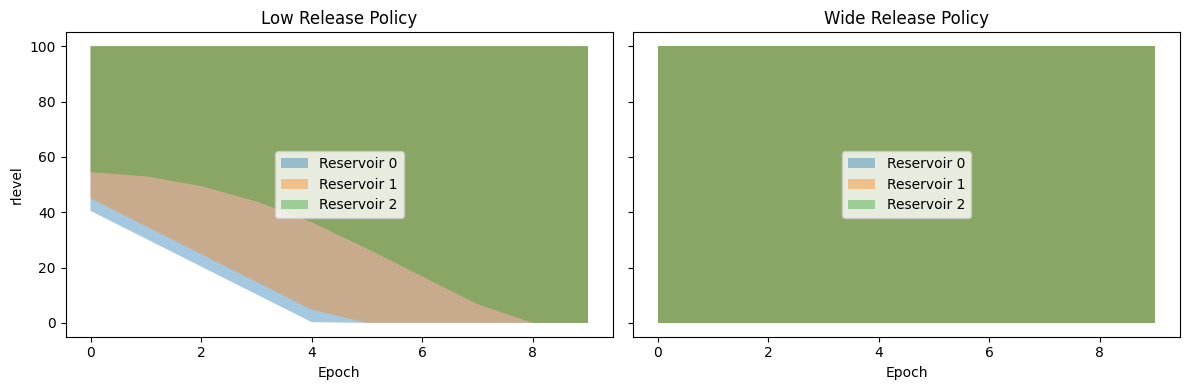

In [7]:
%matplotlib inline
epochs = np.arange(low_bounds['rlevel'][0].shape[0])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i in range(3):
    axes[0].fill_between(epochs, 
                         low_bounds['rlevel'][0][:, i], 
                         low_bounds['rlevel'][1][:, i], 
                         alpha=0.4, label=f'Reservoir {i}')
    axes[0].set_title('Low Release Policy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('rlevel'); axes[0].legend()

for i in range(3):
    axes[1].fill_between(epochs, 
                         wide_bounds['rlevel'][0][:, i], 
                         wide_bounds['rlevel'][1][:, i], 
                         alpha=0.4, label=f'Reservoir {i}')
    axes[1].set_title('Wide Release Policy')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

Interval analysis on the support is usually too loose because it uses inf bounds on random variables with infinite support (such as Gaussian) - this is the reason why the minimum return is uninformative above. However, extreme values in this interval are exceedingly unlikely to occur in practice, rendering the resulting intervals uninformative. Instead, we can use high-probability  bounds that contain p percent of the probability mass, which is typically sufficient for large enough p.

Let's repeat the previous analysis, but this time we use the 5 and 95 percentiles in the interval arithmetic calculations:

In [8]:
analysis = RDDLIntervalAnalysisPercentile(env.model, (0.05, 0.95))
low_bounds = analysis.bound(low_policy, per_epoch=True)
wide_bounds = analysis.bound(wide_policy, per_epoch=True)

low_return_low_bounds = np.sum(low_bounds['reward'][0], axis=0)
low_return_high_bounds = np.sum(low_bounds['reward'][1], axis=0)
wide_return_low_bounds = np.sum(wide_bounds['reward'][0], axis=0)
wide_return_high_bounds = np.sum(wide_bounds['reward'][1], axis=0)
print(f"Low release policy return bounds: [{low_return_low_bounds}, {low_return_high_bounds}]")
print(f"Wide release policy return bounds: [{wide_return_low_bounds}, {wide_return_high_bounds}]")


Low release policy return bounds: [-1528.68504877471, 8799.252117260374]
Wide release policy return bounds: [-4000.0, 24000.0]


As you can see, percentile bounds return tighter bounds on the policy, at the expense of slight statistical significance.